In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import yfinance as yf
from datetime import time
sys.path.append(os.path.abspath("../src"))
from data_cleaner import DataCleanerConfig, DataCleaner, preprocess_data

# Para ir tocando data_cleaner sin tener que reiniciar el kernel
%load_ext autoreload
%autoreload 2

In [3]:
# Configuración para datos a 5m
cfg_5m = DataCleanerConfig(
    source="alpaca",
    symbol="QQQ",
    interval="5m",
    start_date="2022-01-01",
    end_date="2026-01-02",
   
)

cleaner = DataCleaner(cfg_5m)
df_raw = cleaner.cargar_datos()
df = preprocess_data(df_raw)

df

,symbol,datetime,open,high,low,close,volume,trade_count,vwap,volume_norm,...,log_ret_ch,log_ret_cl,log_ret_vwap,log_return_lag1,log_return_lag3,log_return_lag5,vol_rolling,rsi,macd,macd_signal
0,QQQ,2022-01-03 10:40:00+00:00,400.0700,400.08,400.03,400.0300,928.0,26.0,400.053334,-1.038042,...,-0.000125,0.000000,-0.000083,0.000275,0.000200,-0.000100,0.000261,77.599999,0.000423,0.000313
1,QQQ,2022-01-03 10:45:00+00:00,400.0200,400.07,400.00,400.0700,1083.0,38.0,400.032727,-0.923369,...,0.000000,0.000175,-0.000052,-0.000200,-0.000200,0.000300,0.000260,76.666666,0.000430,0.000336
2,QQQ,2022-01-03 10:50:00+00:00,400.0100,400.07,399.96,400.0500,4364.0,43.0,400.017493,-0.269167,...,-0.000050,0.000225,-0.000038,0.000100,0.000275,0.000200,0.000255,75.206611,0.000427,0.000354
3,QQQ,2022-01-03 10:55:00+00:00,400.0700,400.07,400.07,400.0700,208.0,5.0,400.070000,-0.973547,...,0.000000,0.000000,0.000131,-0.000050,-0.000200,-0.000200,0.000225,73.451327,0.000424,0.000368
4,QQQ,2022-01-03 11:00:00+00:00,400.1500,400.40,400.15,400.3500,5741.0,83.0,400.314086,0.077401,...,-0.000125,0.000500,0.000610,0.000050,0.000100,0.000275,0.000257,77.272726,0.000472,0.000389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189326,QQQ,2026-01-01 00:35:00+00:00,614.2984,614.32,614.24,614.2639,635.0,48.0,614.287381,-0.986389,...,-0.000091,0.000039,0.000025,0.000016,-0.000080,0.000016,0.000053,41.026336,-0.000044,-0.000070
189327,QQQ,2026-01-01 00:40:00+00:00,614.3000,614.30,614.30,614.3000,129.0,12.0,614.300000,-1.211694,...,0.000000,0.000000,0.000021,-0.000059,-0.000018,0.000065,0.000053,48.699270,-0.000040,-0.000064
189328,QQQ,2026-01-01 00:45:00+00:00,614.2800,614.32,614.28,614.3085,991.0,48.0,614.301639,-0.593634,...,-0.000019,0.000046,0.000003,0.000059,0.000016,-0.000080,0.000053,49.948952,-0.000036,-0.000058
189329,QQQ,2026-01-01 00:50:00+00:00,614.2903,614.30,614.23,614.2400,4718.0,128.0,614.258774,1.783280,...,-0.000098,0.000016,-0.000070,0.000014,-0.000059,-0.000018,0.000059,42.378047,-0.000040,-0.000055


In [67]:
df.columns

Index(['symbol', 'datetime', 'open', 'high', 'low', 'close', 'volume',
       'trade_count', 'vwap', 'volume_norm', 'trade_count_norm', 'return',
       'log_return_close', 'log_return_norm', 'log_ret_oc', 'log_ret_hl',
       'log_ret_ch', 'log_ret_cl', 'log_ret_vwap', 'log_return_lag1',
       'log_return_lag3', 'log_return_lag5', 'vol_rolling', 'rsi', 'macd',
       'macd_signal', 'fwd_logret_2h', 'direction_2h'],
      dtype='object')

In [101]:
HORIZON = 24  # 24 velas de 5m = 2 horas
df = df.copy()
df["datetime"] = pd.to_datetime(df["datetime"], utc=True, errors="coerce")
df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

# TARGET

## Aseguramos el horario de Nueva York
df["date_ny"] = df["datetime"].dt.tz_convert("America/New_York").dt.date

# el close future no es mas que el precio futuro que se quiere predecir (Esta vez de  la columna date_ny, que indica el del horario de nueva york)
df["close_future"] = df.groupby("date_ny")["close"].shift(-HORIZON)

# elimina las ultimas filas ya que no tenemos datos de ses futuro
df = df.dropna(subset=["close_future"]).reset_index(drop=True)

# la variable direccion compara el precio futuro con el actual, si es mayor guarda 1, y si es menor o igual 0
thr = 0.0005
df["fwd_logret_2h"] = np.log(df["close_future"] / df["close"])

df["direction_2h"] = 1
df.loc[df["fwd_logret_2h"] >  thr, "direction_2h"] = 2
df.loc[df["fwd_logret_2h"] < -thr, "direction_2h"] = 0
df["direction_2h"] = df["direction_2h"].astype(np.int8)

FEATURE_COLUMNS = [
    "log_ret_hl",
    "vwap",
    "vol_rolling",
    "volume"
]

# trade count no es otra cosa que el numero de operaciones que se realizan en el periodo de tiempo de una vela
# trade_count: usa norm si existe, si no raw (y si no existe, no pasa nada)
if "trade_count_norm" in df.columns:
    FEATURE_COLUMNS.append("trade_count_norm")
elif "trade_count" in df.columns:
    FEATURE_COLUMNS.append("trade_count")

# 1-2 extras "seguros" (si existen)
# log_return_norm --> retorno calculado con logaritmos
# log_ret_vwap --> logaritmo del precio medio ponderado por volumen
for c in ["log_return_norm", "log_ret_vwap"]:
    if c in df.columns:
        FEATURE_COLUMNS.append(c)

# quitar las que no existan (por si Alpaca/YF no trae alguna)
FEATURE_COLUMNS = [c for c in FEATURE_COLUMNS if c in df.columns]

# Limpieza de columnas auxiliares
df = df.drop(columns=[c for c in ["close_future", "date_ny"] if c in df.columns])

print("N features:", len(FEATURE_COLUMNS))
print("FEATURE_COLUMNS:", FEATURE_COLUMNS)
print("Rows df:", len(df))

print("direction_2h" in df.columns)
print(df[["close", "direction_2h"]].head())
 

N features: 7
FEATURE_COLUMNS: ['log_ret_hl', 'vwap', 'vol_rolling', 'volume', 'trade_count_norm', 'log_return_norm', 'log_ret_vwap']
Rows df: 93043
True
    close  direction_2h
0  400.03             2
1  400.07             1
2  400.05             1
3  400.07             1
4  400.35             1


True
Columnas numéricas:
['open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap', 'volume_norm', 'trade_count_norm', 'return', 'log_return_close', 'log_return_norm', 'log_ret_oc', 'log_ret_hl', 'log_ret_ch', 'log_ret_cl', 'log_ret_vwap', 'log_return_lag1', 'log_return_lag3', 'log_return_lag5', 'vol_rolling', 'rsi', 'macd', 'macd_signal', 'fwd_logret_2h', 'direction_2h']


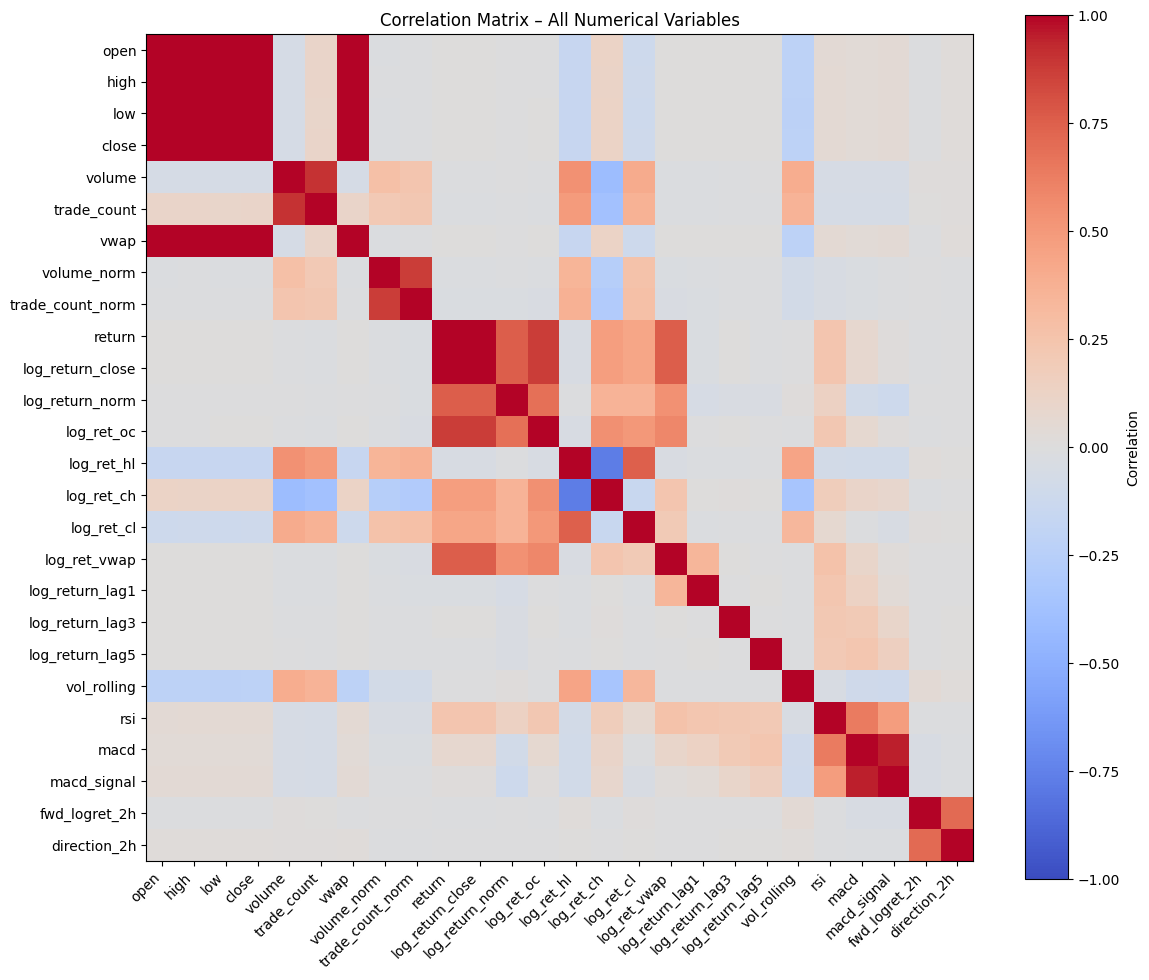

In [102]:
# Columnas numéricas del dataframe

num_cols = df.select_dtypes(include=["int64","int32","float64","float32","int8","int16","float16"]).columns.tolist()
print("direction_2h" in num_cols)


print("Columnas numéricas:")
print(num_cols)

corr_all = df[num_cols].corr()
corr_all["direction_2h"].sort_values(ascending=False)


corr_all = df[num_cols].corr()

corr_all

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 10))
plt.imshow(corr_all, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_all.columns)), corr_all.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_all.index)), corr_all.index)

plt.title("Correlation Matrix – All Numerical Variables")
plt.tight_layout()
plt.show()


### Sanity Check: Correlación de las variable con la variable target

In [103]:
corr_target = corr_all["direction_2h"].sort_values(ascending=False)
print(corr_target)


direction_2h        1.000000
fwd_logret_2h       0.704791
vol_rolling         0.017647
high                0.017259
open                0.017255
close               0.017247
vwap                0.017246
low                 0.017234
volume              0.013440
trade_count         0.010986
log_ret_hl          0.003557
log_ret_cl          0.002815
log_return_lag5     0.001132
log_return_lag3     0.000936
log_ret_vwap       -0.001414
log_return_norm    -0.001476
log_return_close   -0.001881
return             -0.001884
log_ret_oc         -0.002018
log_return_lag1    -0.002276
log_ret_ch         -0.002569
volume_norm        -0.010352
rsi                -0.010788
trade_count_norm   -0.014607
macd               -0.018124
macd_signal        -0.020164
Name: direction_2h, dtype: float64


### Función de selección por correlación

In [104]:
def select_features_by_correlation(
    df,
    feature_cols,
    target_col,
    min_corr_target=0.02,
    max_corr_between=0.9
):
    """
    Selecciona features útiles según:
    - correlación mínima con el target
    - no redundancia entre features
    """

    # 1) correlación con el target
    corr_target = (
        df[feature_cols + [target_col]]
        .corr()[target_col]
        .drop(target_col)
        .abs()
        .sort_values(ascending=False)
    )

    # 2) filtrado por correlación mínima con target
    selected = corr_target[corr_target >= min_corr_target].index.tolist()

    # 3) eliminar redundancia entre features
    corr_features = df[selected].corr().abs()
    final_features = []

    for f in selected:
        keep = True
        for g in final_features:
            if corr_features.loc[f, g] > max_corr_between:
                keep = False
                break
        if keep:
            final_features.append(f)

    return final_features, corr_target

In [105]:
num_cols , corr_target = select_features_by_correlation(
    df,
    FEATURE_COLUMNS,
    target_col="direction_2h",
    min_corr_target=0.02,
    max_corr_between=0.9
)

print("Selected features:", num_cols)
print("\nCorrelation with target:")
print(corr_target)

Selected features: []

Correlation with target:
vol_rolling         0.017647
vwap                0.017246
trade_count_norm    0.014607
volume              0.013440
log_ret_hl          0.003557
log_return_norm     0.001476
log_ret_vwap        0.001414
Name: direction_2h, dtype: float64


In [106]:
# Define fechas clave para el test/val/train
VAL_START  = pd.Timestamp("2024-12-01", tz="UTC")
TEST_START = pd.Timestamp("2025-01-01", tz="UTC")
TEST_END   = pd.Timestamp("2026-01-01", tz="UTC")  # exclusivo

embargo = pd.Timedelta(hours=2)  # = horizonte (2h)

# Marca los limites del dataframe de train y de val
TRAIN_END = VAL_START - embargo
VAL_END   = TEST_START - embargo

# Creamos los dataframes de train/val/test
# val es el test real y test es el backtest que se usa para ver si la estrategia es viable a lo largo del tiempo
df_train = df[df["datetime"] < TRAIN_END].copy()
df_val   = df[(df["datetime"] >= VAL_START) & (df["datetime"] < VAL_END)].copy()
df_test  = df[(df["datetime"] >= TEST_START) & (df["datetime"] < TEST_END)].copy()

print("train:", df_train["datetime"].min(), "->", df_train["datetime"].max(), "| rows:", len(df_train))
print("val:  ", df_val["datetime"].min(),   "->", df_val["datetime"].max(),   "| rows:", len(df_val))
print("test: ", df_test["datetime"].min(),  "->", df_test["datetime"].max(),  "| rows:", len(df_test))

print("P(y=1) train:", df_train["direction_2h"].mean())
print("P(y=1) val:  ", df_val["direction_2h"].mean())
print("P(y=1) test: ", df_test["direction_2h"].mean())

train: 2022-01-03 10:40:00+00:00 -> 2024-11-29 13:50:00+00:00 | rows: 67378
val:   2024-12-02 09:00:00+00:00 -> 2024-12-31 16:25:00+00:00 | rows: 1926
test:  2025-01-02 09:00:00+00:00 -> 2025-12-31 16:55:00+00:00 | rows: 23739
P(y=1) train: 1.0276944996883255
P(y=1) val:   1.173416407061267
P(y=1) test:  1.0591853068789756


Vemos que las clases estan balanceadas, ya que las medias estan entorno 0,5. No creo que haga falta balancear las clases, ya que no cambiará mucho el valor de loss con ese desbalanceo tan pequeño.

### Sanity Check: clase target alineada en el tiempo
Realizaremos un Snaity Check para ver si la clase direction_2h esta alineada o no en el tiempo

In [107]:
# Sanity Check para variable direction_2h

idx = 1000

df.loc[idx, ["datetime", "close", "direction_2h"]]


datetime        2022-01-19 10:45:00+00:00
close                              371.56
direction_2h                            1
Name: 1000, dtype: object

In [108]:
df.loc[idx+24, ["datetime", "close"]]

datetime    2022-01-19 12:45:00+00:00
close                          371.67
Name: 1024, dtype: object

Ya hemos comprobado que efectivamente para la clase target `direction_2h` se cumple que se ve el precio a futuro a dos horas con su cierre, y que es mayor, por tanto la `direction_2h` es 1 como nos sale.

In [109]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# ---------- scaler para LSTM (solo FEATURE_COLUMNS) ----------
scaler_feats = StandardScaler()

X_train_raw = df_train[FEATURE_COLUMNS].values
X_val_raw   = df_val[FEATURE_COLUMNS].values
X_test_raw  = df_test[FEATURE_COLUMNS].values

X_train_scaled = scaler_feats.fit_transform(X_train_raw)
X_val_scaled   = scaler_feats.transform(X_val_raw)
X_test_scaled  = scaler_feats.transform(X_test_raw)

df_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_COLUMNS)
df_train_scaled["datetime"] = df_train["datetime"].values
df_train_scaled["direction_2h"] = df_train["direction_2h"].values

df_val_scaled = pd.DataFrame(X_val_scaled, columns=FEATURE_COLUMNS)
df_val_scaled["datetime"] = df_val["datetime"].values
df_val_scaled["direction_2h"] = df_val["direction_2h"].values

df_test_scaled = pd.DataFrame(X_test_scaled, columns=FEATURE_COLUMNS)
df_test_scaled["datetime"] = df_test["datetime"].values
df_test_scaled["direction_2h"] = df_test["direction_2h"].values


# ---------- scaler para LOGISTIC (todas las numéricas) ----------
# crea num_cols DESDE df_train
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
for col in ["direction_2h", "target_2h"]:
    if col in num_cols:
        num_cols.remove(col)

print("num_cols len:", len(num_cols))

scaler_all = StandardScaler()

X_train_raw_l = df_train[num_cols].values
X_val_raw_l   = df_val[num_cols].values
X_test_raw_l  = df_test[num_cols].values

X_train_scaled_l = scaler_all.fit_transform(X_train_raw_l)
X_val_scaled_l   = scaler_all.transform(X_val_raw_l)
X_test_scaled_l  = scaler_all.transform(X_test_raw_l)

df_train_scaled_logistic = pd.DataFrame(X_train_scaled_l, columns=num_cols)
df_val_scaled_logistic   = pd.DataFrame(X_val_scaled_l, columns=num_cols)
df_test_scaled_logistic  = pd.DataFrame(X_test_scaled_l, columns=num_cols)

# añade el target
df_train_scaled_logistic["direction_2h"] = df_train["direction_2h"].values
df_val_scaled_logistic["direction_2h"]   = df_val["direction_2h"].values
df_test_scaled_logistic["direction_2h"]  = df_test["direction_2h"].values


num_cols len: 25


### Sanity Check: Escalado de datasets
Antes de terminar con el escalado de los datos, comprobamos que ninguno de los datos, ni de train, val ni test sean nulos o tiendan a infinito.

In [110]:
def check_df(df, name, feature_cols):
    print(f"\n{name}")

    # Check global
    has_nan = df.isna().any().any()
    has_inf = np.isinf(df[feature_cols].values).any() if len(feature_cols) > 0 else False
    print(f"Global -> NaN: {has_nan} | INF: {has_inf}")

    # Columnas que queremos mirar si existen
    wanted = list(feature_cols) + ["direction_2h", "datetime"]
    cols_present = [c for c in wanted if c in df.columns]
    cols_missing = [c for c in wanted if c not in df.columns]

    if cols_missing:
        print("Missing columns (skip):", cols_missing)

    # NaNs por columna (solo presentes)
    nan_counts = df[cols_present].isna().sum()

    if nan_counts.sum() == 0:
        print("NaNs por columna: OK (0 en todas)")
    else:
        print("NaNs por columna:")
        print(nan_counts[nan_counts > 0])

        

check_df(df_train_scaled, "TRAIN", FEATURE_COLUMNS)
check_df(df_val_scaled,   "VAL",   FEATURE_COLUMNS)
check_df(df_test_scaled,  "TEST",  FEATURE_COLUMNS)

check_df(df_train_scaled_logistic, "TRAIN LOGISTIC", num_cols)
check_df(df_val_scaled_logistic, "VAL LOGISTIC", num_cols)
check_df(df_test_scaled_logistic, "TEST LOGISTIC", num_cols)

print(df_train_scaled_logistic.columns.to_list())
print(df_val_scaled_logistic.columns.to_list())
print(df_test_scaled_logistic.columns.to_list())




TRAIN
Global -> NaN: False | INF: False
NaNs por columna: OK (0 en todas)

VAL
Global -> NaN: False | INF: False
NaNs por columna: OK (0 en todas)

TEST
Global -> NaN: False | INF: False
NaNs por columna: OK (0 en todas)

TRAIN LOGISTIC
Global -> NaN: False | INF: False
Missing columns (skip): ['datetime']
NaNs por columna: OK (0 en todas)

VAL LOGISTIC
Global -> NaN: False | INF: False
Missing columns (skip): ['datetime']
NaNs por columna: OK (0 en todas)

TEST LOGISTIC
Global -> NaN: False | INF: False
Missing columns (skip): ['datetime']
NaNs por columna: OK (0 en todas)
['open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap', 'volume_norm', 'trade_count_norm', 'return', 'log_return_close', 'log_return_norm', 'log_ret_oc', 'log_ret_hl', 'log_ret_ch', 'log_ret_cl', 'log_ret_vwap', 'log_return_lag1', 'log_return_lag3', 'log_return_lag5', 'vol_rolling', 'rsi', 'macd', 'macd_signal', 'fwd_logret_2h', 'direction_2h']
['open', 'high', 'low', 'close', 'volume', 'trade_count', 'vw

## Regresion lógistica para elección de features

In [111]:
# Identifica columnas sospechas que pueden dar data_leakage
leak_patterns = [
    "fwd", "future", "lead", "ahead", "next", "close_future", "target",
    "t+"
]

all_cols = df_train_scaled_logistic.columns.tolist()

suspects = [c for c in all_cols if any(p in c.lower() for p in leak_patterns)]
print("SUSPECTS:", suspects)

target_col = "direction_2h"

feature_cols_all = [c for c in df_train_scaled_logistic.columns if c != target_col]

safe_features = [
    c for c in feature_cols_all
    if not any(p in c.lower() for p in leak_patterns)
]

print("Total features:", len(feature_cols_all))
print("Safe features:", len(safe_features))
print("Removed:", [c for c in feature_cols_all if c not in safe_features][:50])

SUSPECTS: ['fwd_logret_2h']
Total features: 25
Safe features: 24
Removed: ['fwd_logret_2h']


In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

def train_eval_logistic(df_train, df_val, feature_cols, target_col):
    X_train = df_train[feature_cols].values
    y_train = df_train[target_col].values
    X_val = df_val[feature_cols].values
    y_val = df_val[target_col].values

    clf = LogisticRegression(solver="lbfgs", max_iter=5000, n_jobs=-1)
    clf.fit(X_train, y_train)

    probs_val = clf.predict_proba(X_val)
    val_ce = log_loss(y_val, probs_val, labels=clf.classes_)

    return val_ce, clf

val_ce_safe, clf_safe = train_eval_logistic(
    df_train_scaled_logistic,
    df_val_scaled_logistic,
    safe_features,
    target_col="direction_2h"
)

print("VAL CE (safe):", val_ce_safe)

/Users/alejandrovazquezramirez/Desktop/ProyectosIA/TRADING_ALG/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


VAL CE (safe): 1.0265961864937132


In [113]:
df_train_shuf = df_train_scaled_logistic.copy()
df_train_shuf["direction_2h"] = np.random.permutation(df_train_shuf["direction_2h"].values)

val_ce_shuf, _ = train_eval_logistic(
    df_train_shuf,
    df_val_scaled_logistic,
    safe_features,
    target_col="direction_2h"
)

print("VAL CE with SHUFFLED y (should be ~baseline):", val_ce_shuf)


/Users/alejandrovazquezramirez/Desktop/ProyectosIA/TRADING_ALG/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


VAL CE with SHUFFLED y (should be ~baseline): 1.0518524282405002


## Elección de mejores features

### Ranking de features individuales
Si el valor de CE de las features es mayor o igual al baseline mal, esa feature no es buena. Si esta cerca de 1.05 señal debil. Si esta entre 1.03-1.04, la feature es buena. Si es menor que 1.02, es muy buena y suele ser raro

In [114]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, balanced_accuracy_score
import numpy as np

def rank_single_features(
    df_train,
    df_val,
    feature_list,
    target_col
):
    results = []

    for f in feature_list:
        X_tr = df_train[[f]].values
        y_tr = df_train[target_col].values

        X_va = df_val[[f]].values
        y_va = df_val[target_col].values

        clf = LogisticRegression(
            solver="lbfgs",
            max_iter=5000
        )
        clf.fit(X_tr, y_tr)

        probs = clf.predict_proba(X_va)
        preds = np.argmax(probs, axis=1)

        ce = log_loss(y_va, probs, labels=clf.classes_)
        bacc = balanced_accuracy_score(y_va, preds)

        results.append({
            "feature": f,
            "val_ce": ce,
            "val_bacc": bacc
        })

    # Ordenamos: mejor primero
    results = sorted(results, key=lambda x: x["val_ce"])
    return results


single_results = rank_single_features(
    df_train_scaled_logistic,
    df_val_scaled_logistic,
    safe_features,
    target_col="direction_2h"
)

for r in single_results[:15]:
    print(f"{r['feature']:25s} | CE={r['val_ce']:.4f} | bAcc={r['val_bacc']:.4f}")


log_ret_hl                | CE=1.0328 | bAcc=0.3333
low                       | CE=1.0366 | bAcc=0.3333
open                      | CE=1.0366 | bAcc=0.3333
vwap                      | CE=1.0366 | bAcc=0.3333
close                     | CE=1.0366 | bAcc=0.3333
high                      | CE=1.0367 | bAcc=0.3333
vol_rolling               | CE=1.0389 | bAcc=0.3209
log_ret_cl                | CE=1.0402 | bAcc=0.3333
log_ret_ch                | CE=1.0416 | bAcc=0.3333
volume                    | CE=1.0420 | bAcc=0.3333
trade_count               | CE=1.0428 | bAcc=0.3333
volume_norm               | CE=1.0457 | bAcc=0.3351
trade_count_norm          | CE=1.0462 | bAcc=0.3374
log_return_lag3           | CE=1.0499 | bAcc=0.3333
log_return_lag1           | CE=1.0500 | bAcc=0.3333


### Ranking por coeficientes del modelo
Ahora vemos qué features pesan más cuando el modelo las usa todas. Esto no sirve para seleccionar directamente, pero da intuición.

In [115]:
clf = LogisticRegression(
    solver="lbfgs",
    max_iter=5000
)

X_tr = df_train_scaled_logistic[safe_features].values
y_tr = df_train_scaled_logistic["direction_2h"].values

clf.fit(X_tr, y_tr)

coef_importance = np.mean(np.abs(clf.coef_), axis=0)

coef_rank = sorted(
    zip(safe_features, coef_importance),
    key=lambda x: x[1],
    reverse=True
)

for f, w in coef_rank[:15]:
    print(f"{f:25s} | coef_abs={w:.4f}")


macd                      | coef_abs=0.1354
macd_signal               | coef_abs=0.1164
volume                    | coef_abs=0.0720
rsi                       | coef_abs=0.0683
vol_rolling               | coef_abs=0.0607
trade_count_norm          | coef_abs=0.0583
trade_count               | coef_abs=0.0559
log_ret_cl                | coef_abs=0.0518
log_ret_hl                | coef_abs=0.0476
log_ret_ch                | coef_abs=0.0201
return                    | coef_abs=0.0199
log_ret_vwap              | coef_abs=0.0154
log_return_close          | coef_abs=0.0152
log_return_lag3           | coef_abs=0.0151
low                       | coef_abs=0.0147


### Combinaciones pequeñas (k=2 y k=3)

In [116]:
import itertools

def rank_feature_combinations(
    df_train,
    df_val,
    feature_list,
    target_col,
    k=2,
    top_n=20
):
    results = []

    for combo in itertools.combinations(feature_list, k):
        X_tr = df_train[list(combo)].values
        y_tr = df_train[target_col].values

        X_va = df_val[list(combo)].values
        y_va = df_val[target_col].values

        clf = LogisticRegression(
            solver="lbfgs",
            max_iter=5000
        )
        clf.fit(X_tr, y_tr)

        probs = clf.predict_proba(X_va)
        preds = np.argmax(probs, axis=1)

        ce = log_loss(y_va, probs, labels=clf.classes_)
        bacc = balanced_accuracy_score(y_va, preds)

        results.append({
            "features": combo,
            "val_ce": ce,
            "val_bacc": bacc
        })

    results = sorted(results, key=lambda x: x["val_ce"])
    return results[:top_n]

top_single_features = [r["feature"] for r in single_results[:15]]

top_pairs = rank_feature_combinations(
    df_train_scaled_logistic,
    df_val_scaled_logistic,
    top_single_features,
    target_col="direction_2h",
    k=2,
    top_n=15
)

for r in top_pairs:
    print(f"{r['features']} | CE={r['val_ce']:.4f} | bAcc={r['val_bacc']:.4f}")


('log_ret_hl', 'high') | CE=1.0248 | bAcc=0.3333
('log_ret_hl', 'low') | CE=1.0248 | bAcc=0.3333
('log_ret_hl', 'vwap') | CE=1.0248 | bAcc=0.3333
('log_ret_hl', 'open') | CE=1.0248 | bAcc=0.3333
('log_ret_hl', 'close') | CE=1.0249 | bAcc=0.3333
('low', 'vol_rolling') | CE=1.0294 | bAcc=0.3333
('vwap', 'vol_rolling') | CE=1.0294 | bAcc=0.3333
('open', 'vol_rolling') | CE=1.0294 | bAcc=0.3333
('close', 'vol_rolling') | CE=1.0294 | bAcc=0.3333
('high', 'vol_rolling') | CE=1.0294 | bAcc=0.3333
('low', 'log_ret_cl') | CE=1.0298 | bAcc=0.3333
('vwap', 'log_ret_cl') | CE=1.0298 | bAcc=0.3333
('close', 'log_ret_cl') | CE=1.0298 | bAcc=0.3333
('open', 'log_ret_cl') | CE=1.0298 | bAcc=0.3333
('high', 'log_ret_cl') | CE=1.0298 | bAcc=0.3333


In [117]:
"""import torch
from torch.utils.data import Dataset, DataLoader

class SlidingWindowDataset(Dataset):
    def __init__(self, df, feature_cols, target_col="direction_2h", seq_len=128):
        # seq_len es cuantas filas pasadas le doy al modelo para que prediga 
        self.seq_len = seq_len
        self.feature_cols = feature_cols
        
        # Convertimos a tensores para PyTorch
        self.features = torch.tensor(df[feature_cols].values, dtype=torch.float32)
        self.targets = torch.tensor(df[target_col].values, dtype=torch.float32)
        
        # Guardamos timestamps en formato string (por simplicidad)
        self.timestamps = pd.to_datetime(df["datetime"]).values.astype("datetime64[ns]")

    def __len__(self):
        # devuelve el numero de filas menos la len de la secuencia mas uno
        return len(self.features) - self.seq_len + 1

    def __getitem__(self, idx):
        # Secuencia de tamaño seq_len
        x = self.features[idx : idx + self.seq_len]

        # Target para horizon = seq_len + 24 (pero ya está hecho en target_2h)
        y = self.targets[idx + self.seq_len -1]

        # Timestamp del momento donde hacemos la predicción
        ts = self.timestamps[idx + self.seq_len -1].astype("datetime64[ns]").astype(np.int64) 

        return x, y, ts
"""

'import torch\nfrom torch.utils.data import Dataset, DataLoader\n\nclass SlidingWindowDataset(Dataset):\n    def __init__(self, df, feature_cols, target_col="direction_2h", seq_len=128):\n        # seq_len es cuantas filas pasadas le doy al modelo para que prediga \n        self.seq_len = seq_len\n        self.feature_cols = feature_cols\n\n        # Convertimos a tensores para PyTorch\n        self.features = torch.tensor(df[feature_cols].values, dtype=torch.float32)\n        self.targets = torch.tensor(df[target_col].values, dtype=torch.float32)\n\n        # Guardamos timestamps en formato string (por simplicidad)\n        self.timestamps = pd.to_datetime(df["datetime"]).values.astype("datetime64[ns]")\n\n    def __len__(self):\n        # devuelve el numero de filas menos la len de la secuencia mas uno\n        return len(self.features) - self.seq_len + 1\n\n    def __getitem__(self, idx):\n        # Secuencia de tamaño seq_len\n        x = self.features[idx : idx + self.seq_len]\n\n

In [118]:
"""Sliding Window con stride (menor correlación y ejemplos más independientes)"""
import torch
from torch.utils.data import Dataset, DataLoader

class SlidingWindowDatasetStride(Dataset):
    def __init__(self, df, feature_cols, target_col="direction_2h", seq_len=128, stride=4):
        """
        df: dataframe escalado con columnas features + datetime + target
        seq_len: cuántas filas pasadas ve el modelo
        stride: cada cuántas filas se crea una nueva ventana
        """
        self.seq_len = seq_len
        self.stride = stride
        self.feature_cols = feature_cols
        
        # Convertimos a tensores para PyTorch
        self.features = torch.tensor(df[feature_cols].values, dtype=torch.float32)
        self.targets  = torch.tensor(df[target_col].values, dtype=torch.long)
        
        # Guardamos timestamps
        self.timestamps = pd.to_datetime(df["datetime"]).values.astype("datetime64[ns]")

    def __len__(self):
        # Número de ventanas teniendo en cuenta el stride
        return max(0, (len(self.features) - self.seq_len) // self.stride + 1)

    def __getitem__(self, i):
        # Índice real teniendo en cuenta el stride
        idx = i * self.stride
        
        # Secuencia de tamaño seq_len
        x = self.features[idx : idx + self.seq_len]

        # Target asociado al último timestep de la ventana
        y = self.targets[idx + self.seq_len - 1]

        # Timestamp del momento de la predicción
        ts = self.timestamps[idx + self.seq_len - 1].astype(np.int64)

        return x, y, ts

In [119]:
SEQ_LEN = 64  # ventana de observación (64 velas)
STRIDE = 4 # saltos entre ventana y ventana

# Usamos la clase anterior para definir los datos de entrenamiento, de validations y de back-test
train_dataset = SlidingWindowDatasetStride(
    df_train_scaled,
    feature_cols=FEATURE_COLUMNS,
    target_col="direction_2h",
    seq_len=SEQ_LEN,
    stride=STRIDE
)

val_dataset = SlidingWindowDatasetStride(
    df_val_scaled,
    feature_cols=FEATURE_COLUMNS,
    target_col="direction_2h",
    seq_len=SEQ_LEN,
    stride=STRIDE
)

test_dataset = SlidingWindowDatasetStride(
    df_test_scaled,
    feature_cols=FEATURE_COLUMNS,
    target_col="direction_2h",
    seq_len=SEQ_LEN,
    stride=STRIDE
)

print(len(train_dataset), len(val_dataset), len(test_dataset))
# Comprobación rápida para estar seguros
print(len(df_train_scaled))
print(len(train_dataset))
# SI len(train_dataset) ≈ (len(df_train_scaled) - SEQ_LEN) // STRIDE + 1 todo Bien
print((len(df_train_scaled) - SEQ_LEN) // STRIDE + 1)



16829 466 5919
67378
16829
16829


In [120]:
# Definimos el BATCH SIZE y cargamos los datos para que sean entrenados
# Usamos shuffle=True en train_loader porque estamos usando STRIDE. Si no podría ser False dependiendo del caso
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)


### Sanity Check: Verificación final del pipeline de datos

In [121]:
# Ver un batch
xb, yb, tsb = next(iter(train_loader))

print("Batch X:", xb.shape)   # (batch, seq_len, num_features)
print("Batch y:", yb.shape)   # (batch,)
print("Timestamp example:", tsb[0])


Batch X: torch.Size([64, 64, 7])
Batch y: torch.Size([64])
Timestamp example: tensor(1649691600000000000)


# Ahora la LSTM

In [122]:
import torch.nn as nn

class LockedDropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.p = p      # probabilidad de apagar una neurona 

    def forward(self, x):
        # x: (B, T, F)
        # En este primer caso no se aplica dropout
        if (not self.training) or self.p == 0.0:
            return x
        # misma máscara para todos los timesteps (deciden que features tendrán menor peso en función de p)
        mask = x.new_empty((x.size(0), 1, x.size(2))).bernoulli_(1 - self.p)
        mask = mask / (1 - self.p)
        return x * mask


In [123]:
import torch.nn as nn

class LSTMRegressor_VDROP(nn.Module):
    # input_dim = features, vdrop_in = probabilidad de dropout
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, vdrop_in=0.2):
        super().__init__()
        self.vdrop_in = LockedDropout(vdrop_in)

        # La LSTM en si misma
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=0.0,
            batch_first=True
        )

        # Capa donde normalizamos cada batch
        self.norm = nn.LayerNorm(hidden_dim)
        # Se juntan todas las predicciones de la LSTM para cada batch en un único número (resumen de 64 en la capa hidden a 1)
        self.fc = nn.Linear(hidden_dim, 3)  

    def forward(self, x):
        x = self.vdrop_in(x)
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        last = self.norm(last)
        y = self.fc(last)
        return y

In [124]:
import torch
import torch.nn as nn

class LSTMClassifier_VDROP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, vdrop_in=0.1, lstm_dropout=0.2):
        super().__init__()
        self.vdrop_in = LockedDropout(vdrop_in)

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=(lstm_dropout if num_layers > 1 else 0.0),
            batch_first=True
        )

        # Capa donde normalizamos las filas
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc = nn.Linear(hidden_dim, 3)

    def forward(self, x):
        x = self.vdrop_in(x)
        out, _ = self.lstm(x)          # (B, T, H)
        feat = out.mean(dim=1)         # pooling temporal (B, H)
        feat = self.norm(feat)
        logits = self.fc(feat)
        return logits

In [125]:
input_dim = len(FEATURE_COLUMNS)

model = LSTMClassifier_VDROP(
    input_dim=input_dim,
    hidden_dim=64,
    num_layers=2,
    vdrop_in=0.1
)


### Sanity Check: Cuadramos dimensiones del batch con las dimensiones del feature

In [126]:
xb, yb, _ = next(iter(train_loader))
print("xb features:", xb.shape[-1], "input_dim:", input_dim)

xb features: 7 input_dim: 7


## Opcional
 
Gaussian dropout 

In [127]:
class GaussianDropout(nn.Module):
    def __init__(self, p):
        super().__init__()
        self.p = p

    def forward(self, x):
        if not self.training or self.p == 0.0:
            return x
        # std = sqrt(p / (1 - p))
        std = (self.p / (1.0 - self.p)) ** 0.5
        noise = torch.randn_like(x) * std + 1.0
        return x * noise


## Configuramos el entrenamiento

In [128]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
counts = df_train["direction_2h"].value_counts().reindex([0,1,2], fill_value=0).values.astype(np.float32)
w = 1.0 / (counts + 1e-6)
w = w / w.sum() * 3.0
class_w = torch.tensor(w, device=device, dtype=torch.float32)

criterion = torch.nn.CrossEntropyLoss(weight=class_w)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
model

LSTMClassifier_VDROP(
  (vdrop_in): LockedDropout()
  (lstm): LSTM(7, 64, num_layers=2, batch_first=True, dropout=0.2)
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)

In [129]:
def train_lstm(model, train_loader, val_loader, num_epochs=30, patience=6, min_delta=1e-4, grad_clip=1.0):
    history = {"train_loss": [], "val_loss": []}
    best_val = float("inf")
    best_state = None
    wait = 0

    for epoch in range(1, num_epochs + 1):
        # ---- TRAIN ----
        model.train()
        train_losses = []
        

        for xb, yb, _ in train_loader:
            xb = xb.to(device)
            yb = yb.to(device).long()

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()
            train_losses.append(loss.item())

        # ---- VAL ----
        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb, _ in val_loader:
                xb = xb.to(device)
                yb = yb.to(device).long()

                logits = model(xb)
                loss = criterion(logits, yb)
                val_losses.append(loss.item())

        epoch_train_loss = float(np.mean(train_losses))
        epoch_val_loss = float(np.mean(val_losses))

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)

        print(f"Epoch {epoch:02d} | Train loss: {epoch_train_loss:.6f} | Val loss: {epoch_val_loss:.6f}")

        # ---- EARLY STOPPING ----
        if epoch_val_loss < best_val - min_delta:
            best_val = epoch_val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping en epoch {epoch:02d} | best val: {best_val:.6f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


In [130]:
def train_lstm(model, train_loader, val_loader, num_epochs=30, patience=6, min_delta=1e-4, grad_clip=1.0):
    history = {"train_loss": [], "val_loss": []}
    best_val = float("inf")
    best_state = None
    wait = 0

    for epoch in range(1, num_epochs + 1):
        # ---- TRAIN ----
        model.train()
        train_losses = []
        epoch_logits = None   # Solo se guarda un batch

        for xb, yb, _ in train_loader:
            xb = xb.to(device)
            yb = yb.to(device).long()

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()
            train_losses.append(loss.item())

            # 👇 guardamos logits SOLO del primer batch
            if epoch_logits is None:
                epoch_logits = logits.detach().cpu()

        # ---- LOGITS DIAGNÓSTICO (TRAIN) ----
        probs = torch.softmax(epoch_logits, dim=1)[:, 2]
        print(
            f"Epoch {epoch:02d} | "
            f"softmax(p_up) mean: {probs.mean():.4f} | "
            f"std: {probs.std():.4f}"
        )

        # ---- VAL ----
        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb, _ in val_loader:
                xb = xb.to(device)
                yb = yb.to(device).long()

                logits = model(xb).squeeze(-1)
                loss = criterion(logits, yb)
                val_losses.append(loss.item())

        epoch_train_loss = float(np.mean(train_losses))
        epoch_val_loss = float(np.mean(val_losses))

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)

        print(
            f"Epoch {epoch:02d} | "
            f"Train loss: {epoch_train_loss:.6f} | "
            f"Val loss: {epoch_val_loss:.6f}"
        )

        # ---- EARLY STOPPING ----
        if epoch_val_loss < best_val - min_delta:
            best_val = epoch_val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping en epoch {epoch:02d} | best val: {best_val:.6f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


In [131]:
import numpy as np

def baseline_ce(y, n_classes=3):
    y = np.asarray(y).astype(int)
    counts = np.bincount(y, minlength=n_classes)
    p = counts / counts.sum()
    ce = float(-(p * np.log(p + 1e-12)).sum())
    return ce, p, counts

for name, d in [("train", df_train), ("val", df_val), ("test", df_test)]:
    ce, p, counts = baseline_ce(d["direction_2h"].values, n_classes=3)
    print(f"{name:5s} counts={counts.tolist()} p={np.round(p,4)} baseline_CE={ce:.6f}")


train counts=[28338, 8836, 30204] p=[0.4206 0.1311 0.4483] baseline_CE=0.990355
val   counts=[618, 356, 952] p=[0.3209 0.1848 0.4943] baseline_CE=1.025091
test  counts=[9258, 3818, 10663] p=[0.39   0.1608 0.4492] baseline_CE=1.020625


In [132]:
history = train_lstm(model, train_loader, val_loader, num_epochs=30, patience=6, min_delta=1e-4)
print("best val:", min(history["val_loss"]))


Epoch 01 | softmax(p_up) mean: 0.1742 | std: 0.0363
Epoch 01 | Train loss: 1.089313 | Val loss: 1.060090
Epoch 02 | softmax(p_up) mean: 0.3423 | std: 0.0252
Epoch 02 | Train loss: 1.078918 | Val loss: 1.047501
Epoch 03 | softmax(p_up) mean: 0.3689 | std: 0.0536
Epoch 03 | Train loss: 1.073582 | Val loss: 1.086080
Epoch 04 | softmax(p_up) mean: 0.2577 | std: 0.0591
Epoch 04 | Train loss: 1.074543 | Val loss: 1.039699
Epoch 05 | softmax(p_up) mean: 0.3616 | std: 0.0496
Epoch 05 | Train loss: 1.070760 | Val loss: 1.032040
Epoch 06 | softmax(p_up) mean: 0.3234 | std: 0.0474
Epoch 06 | Train loss: 1.070267 | Val loss: 1.027550
Epoch 07 | softmax(p_up) mean: 0.3697 | std: 0.0483
Epoch 07 | Train loss: 1.070749 | Val loss: 1.034895
Epoch 08 | softmax(p_up) mean: 0.3226 | std: 0.0540
Epoch 08 | Train loss: 1.063853 | Val loss: 1.036645
Epoch 09 | softmax(p_up) mean: 0.3214 | std: 0.0483
Epoch 09 | Train loss: 1.065935 | Val loss: 1.045135
Epoch 10 | softmax(p_up) mean: 0.3708 | std: 0.0483
Epo

In [133]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, classification_report

def get_preds(model, loader, device, threshold=0.5):
    model.eval()
    all_probs, all_y = [], []
    with torch.no_grad():
        for xb, yb, _ in loader:
            xb = xb.to(device)
            yb = yb.to(device).long()
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_y.append(yb.cpu().numpy())
    probs = np.concatenate(all_probs)
    y_true = np.concatenate(all_y).astype(int)
    y_pred = np.argmax(probs, axis=1)
    return y_true, y_pred, probs

y_true, y_pred, probs = get_preds(model, val_loader, device, threshold=0.5)

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)
print("\nClassification report:\n", classification_report(y_true, y_pred, digits=4))
print("\nProb mean/std:", probs.mean(), probs.std())


Confusion matrix:
 [[ 57  59  39]
 [ 17  58   7]
 [ 67 114  48]]

Classification report:
               precision    recall  f1-score   support

           0     0.4043    0.3677    0.3851       155
           1     0.2511    0.7073    0.3706        82
           2     0.5106    0.2096    0.2972       229

    accuracy                         0.3498       466
   macro avg     0.3887    0.4282    0.3510       466
weighted avg     0.4296    0.3498    0.3394       466


Prob mean/std: 0.33333334 0.11269563


In [134]:
from sklearn.metrics import roc_auc_score
print("AUC:", roc_auc_score(y_true, probs, multi_class="ovr"))


AUC: 0.6022605033614133


# CHECKS

In [135]:
import numpy as np
import torch

y_tr = torch.cat([yb for _, yb, _ in train_loader]).cpu().numpy()
y_va = torch.cat([yb for _, yb, _ in val_loader]).cpu().numpy()

print("train %1:", y_tr.mean(), "  count:", len(y_tr))
print("val   %1:", y_va.mean(), "  count:", len(y_va))


train %1: 1.0266801354804207   count: 16829
val   %1: 1.1587982832618027   count: 466


In [136]:
import numpy as np
import torch
from sklearn.metrics import roc_auc_score

def eval_val(model, val_loader, device):
    model.eval()
    probs = []
    ys = []
    with torch.no_grad():
        for xb, yb, _ in val_loader:
            xb = xb.to(device)
            yb = yb.to(device).long()
            logits = model(xb)
            p = torch.softmax(logits, dim=1)  
            probs.append(p.detach().cpu())
            ys.append(yb.detach().cpu())

    probs = torch.cat(probs).numpy()  # <-- (N,3)
    ys = torch.cat(ys).numpy()        # <-- (N,)

    pred = np.argmax(probs, axis=1)   # <-- multiclass
    acc = (pred == ys).mean()
    auc = roc_auc_score(ys, probs, multi_class="ovr")

    print("VAL acc:", acc)
    print("VAL auc:", auc)
    print("prob_up: mean", probs[:, 2].mean(), "min", probs[:, 2].min(), "max", probs[:, 2].max())
    print("prob_up quantiles:", np.quantile(probs[:, 2], [0.01, 0.05, 0.5, 0.95, 0.99]))

eval_val(model, val_loader, device)


VAL acc: 0.3497854077253219
VAL auc: 0.6022605033614133
prob_up: mean 0.33130944 min 0.22625947 max 0.41414616
prob_up quantiles: [0.22731326 0.23613032 0.35174088 0.3960809  0.40945907]


In [137]:
import numpy as np
import torch

UP_CLASS = 2  

def get_prob_up(loader, class_idx=UP_CLASS):
    model.eval()
    ps, ys = [], []
    with torch.no_grad():
        for xb, yb, _ in loader:
            xb = xb.to(device)
            yb = yb.to(device).long()

            logits = model(xb)                          # [B, 3]
            probs  = torch.softmax(logits, dim=1)       # [B, 3]
            p_up   = probs[:, class_idx]                # [B]

            ps.append(p_up.detach().cpu())
            ys.append(yb.detach().cpu())

    return torch.cat(ps).numpy(), torch.cat(ys).numpy()

train_prob_up, train_y = get_prob_up(train_loader)
val_prob_up,   val_y   = get_prob_up(val_loader)

print("train p_up quantiles:", np.quantile(train_prob_up, [0.90, 0.95, 0.97, 0.99]))
print("val   p_up quantiles:", np.quantile(val_prob_up,   [0.90, 0.95, 0.97, 0.99]))

for q in [0.90, 0.95, 0.97, 0.99]:
    thr = float(np.quantile(train_prob_up, q))  # umbral SOLO con train
    mask = val_prob_up >= thr                   # mask 1D (N,)

    hit_rate = (val_y[mask] == UP_CLASS).mean() if mask.any() else np.nan
    print(f"q={q:.2f}  UP_T={thr:.4f}  señales_val={mask.mean():.3%}  %UP_en_señal={hit_rate:.3f}")


train p_up quantiles: [0.4215232  0.42970442 0.43524834 0.44551027]
val   p_up quantiles: [0.38735464 0.3960809  0.40186755 0.40945907]
q=0.90  UP_T=0.4215  señales_val=0.000%  %UP_en_señal=nan
q=0.95  UP_T=0.4297  señales_val=0.000%  %UP_en_señal=nan
q=0.97  UP_T=0.4352  señales_val=0.000%  %UP_en_señal=nan
q=0.99  UP_T=0.4455  señales_val=0.000%  %UP_en_señal=nan


In [138]:
import numpy as np

best_epoch = int(np.argmin(history["val_loss"]) + 1)
print("best epoch:", best_epoch)
print("best val:", float(min(history["val_loss"])))


best epoch: 6
best val: 1.0275500193238258


In [139]:
import numpy as np

p = float(df_val["direction_2h"].mean())
p = np.clip(p, 1e-9, 1-1e-9)
baseline = -(p*np.log(p) + (1-p)*np.log(1-p))

best_val = float(min(history["val_loss"]))

print("p(val):", p)
print("baseline:", float(baseline))
print("best val:", best_val)
print("improve:", float(baseline - best_val))


p(val): 0.999999999
baseline: 2.1723265250352423e-08
best val: 1.0275500193238258
improve: -1.0275499976005606


In [140]:
model.eval()
losses = []
with torch.no_grad():
    for xb, yb, _ in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)

        losses.append(criterion(logits, yb).item())

test_loss = sum(losses) / len(losses)
print("TEST loss:", test_loss)


TEST loss: 1.0518117412444083


In [141]:
import numpy as np
import torch

# baseline en test (por frecuencia)
p_test = df_test["direction_2h"].value_counts(normalize=True).sort_index().reindex([0,1,2], fill_value=0).values.astype(np.float64)
p_test = np.clip(p_test, 1e-12, 1.0)
baseline_test = -np.sum(p_test * np.log(p_test))


model.eval()
losses, losses_flip = [], []
accs, accs_flip = [], []

with torch.no_grad():
    for xb, yb, _ in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)


        # loss normal
        losses.append(criterion(logits, yb).item())

        # loss si el modelo va “al revés”
        losses_flip.append(criterion(logits[:, [2,1,0]], yb).item())


        # accuracy normal
        prob = torch.sigmoid(logits)
        pred = torch.argmax(logits, dim=1)
        accs.append((pred == yb).float().mean().item())


        # accuracy flip
        prob_f = torch.sigmoid(-logits)
        pred_f = torch.argmax(logits[:, [2,1,0]], dim=1)
    accs_flip.append((pred_f == yb).float().mean().item())


test_loss = sum(losses)/len(losses)
test_loss_flip = sum(losses_flip)/len(losses_flip)

print("p(test):", p_test)
print("baseline_test:", baseline_test)
print("TEST loss:", test_loss)
print("TEST loss (flip):", test_loss_flip)
print("acc:", sum(accs)/len(accs))
print("acc (flip):", sum(accs_flip)/len(accs_flip))


p(test): [0.38999115 0.16083239 0.44917646]
baseline_test: 1.020625394585231
TEST loss: 1.0518117412444083
TEST loss (flip): 1.062639037127136
acc: 0.3460750518947519
acc (flip): 0.16129031777381897


In [149]:
import numpy as np
import pandas as pd
import torch

UP_T   = 0.5380  
FEE_BPS_PER_SIDE = 1.0
COST = 0.0
# COST = 2.0 * (FEE_BPS_PER_SIDE / 10000.0)

START_TIME = "15:30"
VOL_COL    = "vol_rolling"   # pon aquí tu GARCH si es otra
VOL_THR = 0.0003

TEST_START = "2025-01-01"
TEST_END   = "2026-01-01"  # exclusivo

def _ts_to_datetime(ts: np.ndarray) -> pd.DatetimeIndex:
    ts = ts.astype("int64")
    m = np.nanmax(ts)
    if m > 1e16: unit = "ns"
    elif m > 1e13: unit = "us"
    elif m > 1e10: unit = "ms"
    else: unit = "s"
    return pd.to_datetime(ts, unit=unit, utc=True, errors="coerce")

def predict_probs(model, loader, device):
    model.eval()
    logits_all, ts_all = [], []
    with torch.no_grad():
        for xb, yb, ts in loader:
            xb = xb.to(device)
            logits = model(xb).detach().cpu().numpy()
            logits_all.append(logits)
            ts_all.append(ts.detach().cpu().numpy())
    logits = np.concatenate(logits_all).astype(np.float64)
    dt = _ts_to_datetime(np.concatenate(ts_all).astype(np.int64))
    e = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs = e / e.sum(axis=1, keepdims=True)
    out = pd.DataFrame({"datetime": dt, "logit": logits[:, 2], "prob_up": probs[:, 2]})
    return out.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

# 1) predicciones SOLO test
pred = predict_probs(model, test_loader, device)

start = pd.Timestamp(TEST_START, tz="UTC")
end   = pd.Timestamp(TEST_END, tz="UTC")
pred = pred[(pred["datetime"] >= start) & (pred["datetime"] < end)].copy()

# 2) returns futuros en test
df_ret = df_test[["datetime", "close", VOL_COL]].copy()
df_ret["datetime"] = pd.to_datetime(df_ret["datetime"], utc=True, errors="coerce")
df_ret = df_ret.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)
df_ret = df_ret[(df_ret["datetime"] >= start) & (df_ret["datetime"] < end)].copy()

df_ret["close_future"] = df_ret["close"].shift(-HORIZON)
df_ret["fwd_logret_2h"] = np.log(df_ret["close_future"] / df_ret["close"])
df_ret = df_ret.dropna(subset=["fwd_logret_2h"]).drop(columns=["close_future"])

bt = pred.merge(df_ret, on="datetime", how="inner").sort_values("datetime").reset_index(drop=True)

# señal
bt["datetime_mad"] = bt["datetime"].dt.tz_convert("Europe/Madrid")
bt = bt[bt["datetime_mad"].dt.strftime("%H:%M") >= START_TIME].copy()

bt["signal"] = ((bt["prob_up"] > UP_T) & (bt[VOL_COL] >= VOL_THR)).astype(np.int8)
bt = bt.sort_values("datetime").reset_index(drop=True)

# trades: entro cuando signal=1 y salgo a HORIZON (sin solapar)
entries = []
i = 0
while i < len(bt) - HORIZON:
    if bt["signal"].iat[i] == 1:
        entries.append(i)
        i += HORIZON
    else:
        i += 1

trades = bt.iloc[entries].copy()

trades["strat_logret"] = trades["fwd_logret_2h"] - COST
trades["equity"] = np.exp(trades["strat_logret"].cumsum())

total_return = (trades["equity"].iloc[-1] - 1.0) if len(trades) else 0.0

if len(trades) >= 3 and trades["strat_logret"].std(ddof=0) > 0:
    mean = trades["strat_logret"].mean()
    std  = trades["strat_logret"].std(ddof=0)
    dt_med = trades["datetime"].diff().dropna().median()
    trades_per_year = (pd.Timedelta(days=365) / dt_med) if pd.notna(dt_med) else np.nan
    sharpe = (mean / std) * np.sqrt(trades_per_year) if pd.notna(trades_per_year) else np.nan
else:
    sharpe = np.nan

print("Backtest 2025")
print("Trades:", len(trades))
print(f"Total return: {total_return*100:.2f}%")
print(f"Sharpe (ann aprox): {sharpe:.2f}")

trades.head()


Backtest 2025
Trades: 0
Total return: 0.00%
Sharpe (ann aprox): nan


,datetime,logit,prob_up,close,vol_rolling,fwd_logret_2h,datetime_mad,signal,strat_logret,equity


In [150]:
import numpy as np
import pandas as pd

def run_bt(bt_base, up_t, vol_thr, cost, horizon, vol_col):
    bt = bt_base.copy()

    # Señal (IGUAL que tu backtest: prob_up > UP_T y vol >= VOL_THR)
    bt["signal"] = ((bt["prob_up"] > up_t) & (bt[vol_col] >= vol_thr)).astype(np.int8)

    # Entradas sin solapar: si entro, salto horizon barras
    entries = []
    i = 0
    while i < len(bt) - int(horizon):
        if bt["signal"].iat[i] == 1:
            entries.append(i)
            i += int(horizon)
        else:
            i += 1

    if len(entries) == 0:
        return 0, 0.0, np.nan

    trades = bt.iloc[entries].copy()

    # Retorno futuro (usa tu columna si existe; si no, la calcula desde close)
    if "fwd_logret_2h" in trades.columns:
        fwd = trades["fwd_logret_2h"].astype(float)
    elif "close" in bt.columns:
        close_future = bt["close"].shift(-int(horizon))
        fwd_all = np.log(close_future / bt["close"])
        fwd = fwd_all.iloc[entries].astype(float)
    else:
        raise ValueError("Falta 'fwd_logret_2h' y no hay 'close' para calcular el retorno futuro.")

    trades["strat_logret"] = fwd - float(cost)
    total_return = float(np.exp(trades["strat_logret"].sum()) - 1.0)

    # Sharpe “por trade” anualizado aproximado con spacing temporal entre trades
    if len(trades) >= 3 and trades["strat_logret"].std(ddof=0) > 0:
        mean = trades["strat_logret"].mean()
        std  = trades["strat_logret"].std(ddof=0)
        dt_med = trades["datetime"].diff().dropna().median()
        trades_per_year = (pd.Timedelta(days=365) / dt_med) if pd.notna(dt_med) else np.nan
        sharpe = float((mean / std) * np.sqrt(trades_per_year)) if pd.notna(trades_per_year) else np.nan
    else:
        sharpe = np.nan

    # OJO: primer retorno = número de trades (para que tu celda actual funcione tal cual)
    return int(len(trades)), total_return, sharpe


In [151]:
import numpy as np
import pandas as pd




MIN_RETURN = 0.25
MIN_TRADES = 30

# grid FINO alrededor del mejor: UP_T~0.5425 y VOL_THR~0.001
UP_T_list = np.round(np.arange(0.5380, 0.5480 + 1e-12, 0.0005), 4)
VOL_list  = np.round(np.arange(0.0005, 0.0015 + 1e-12, 0.0001), 4)

rows = []
bt_base = bt

for u in UP_T_list:
    for v in VOL_list:
        ntr, tret, shp = run_bt(bt_base, float(u), float(v), COST, HORIZON, VOL_COL)
        rows.append({"UP_T": float(u), "VOL_THR": float(v), "trades": int(ntr),
                     "return_%": 100.0*tret, "sharpe": shp})

res_fine = pd.DataFrame(rows)

print("MAX return (fine grid):", res_fine["return_%"].max())

res_ok = res_fine[(res_fine["return_%"] >= 100*MIN_RETURN) & (res_fine["trades"] >= MIN_TRADES)]
if len(res_ok) == 0:
    print("Sigue sin haber combos con return>=25% y trades>=30.")
    print("Si quieres FORZAR >=25%, tienes que: bajar MIN_TRADES, o permitir VOL_THR < 0.001, o apalancar.")
else:
    display(res_ok.sort_values(["sharpe","return_%","trades"], ascending=[False, False, False]).head(30))


MAX return (fine grid): 0.0
Sigue sin haber combos con return>=25% y trades>=30.
Si quieres FORZAR >=25%, tienes que: bajar MIN_TRADES, o permitir VOL_THR < 0.001, o apalancar.


In [152]:
import numpy as np

executed = trades[trades["signal"] != 0].copy()

print("Executed trades:", len(executed), "de", len(trades))
if len(executed) > 0:
    winrate = (executed["strat_logret"] > 0).mean()
    total_ret = np.exp(executed["strat_logret"].sum()) - 1.0
    print("Winrate (executed):", f"{winrate:.2%}")
    print("Total return (executed):", f"{total_ret:.2%}")
else:
    print("No hay trades ejecutados con esos umbrales.")


Executed trades: 0 de 0
No hay trades ejecutados con esos umbrales.


In [153]:
import pandas as pd

def show_range(name, dfx):
    d = pd.to_datetime(dfx["datetime"], utc=True)
    print(f"{name}: {d.min()} -> {d.max()} | rows: {len(dfx)}")

show_range("train", df_train)
show_range("val  ", df_val)
show_range("test ", df_test)


train: 2022-01-03 10:40:00+00:00 -> 2024-11-29 13:50:00+00:00 | rows: 67378
val  : 2024-12-02 09:00:00+00:00 -> 2024-12-31 16:25:00+00:00 | rows: 1926
test : 2025-01-02 09:00:00+00:00 -> 2025-12-31 16:55:00+00:00 | rows: 23739


# Solo un pequeño test para comprobar la parte out of sample

In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) SANITY (mínimo imprescindible)
# =========================
need = ["trades", "df_test", "HORIZON"]
missing = [v for v in need if v not in globals()]
if missing:
    raise ValueError(f"Falta(n) {missing} en memoria. Ejecuta antes la celda que crea trades/df_test/HORIZON.")

# Copias seguras
tr = trades.copy()
dfT = df_test.copy()

# Datetime UTC robusto
for _df, name in [(tr, "trades"), (dfT, "df_test")]:
    _df["datetime"] = pd.to_datetime(_df["datetime"], utc=True, errors="coerce")
    if _df["datetime"].isna().any():
        raise ValueError(f"`{name}['datetime']` tiene NaNs tras parsear. Revisa el formato de datetime.")
    _df.sort_values("datetime", inplace=True)

# =========================
# 1) Rango OOS real (df_test) + embargo
# =========================
test_start = dfT["datetime"].min()
test_end   = dfT["datetime"].max()

# tamaño de barra: intenta df_bt -> df_test -> fallback 5m
bar_delta = None
if "df_bt" in globals():
    try:
        tmp = df_bt.copy()
        tmp["datetime"] = pd.to_datetime(tmp["datetime"], utc=True, errors="coerce")
        bar_delta = tmp["datetime"].diff().dropna().median()
    except Exception:
        bar_delta = None

if bar_delta is None or pd.isna(bar_delta):
    bar_delta = dfT["datetime"].diff().dropna().median()

if bar_delta is None or pd.isna(bar_delta):
    bar_delta = pd.Timedelta(minutes=5)

embargo = bar_delta * int(HORIZON)
strict_start = test_start + embargo

# =========================
# 2) Asegurar columnas necesarias (cost/strat_logret)
# =========================
# cost
if "cost" not in tr.columns:
    if "COST" in globals():
        tr["cost"] = float(COST)
    else:
        tr["cost"] = 0.0

# fwd_logret_2h (para recomputar strat_logret si hace falta)
# (si no existe, no podemos construir estrategia)
if "strat_logret" not in tr.columns:
    if "fwd_logret_2h" not in tr.columns or "signal" not in tr.columns:
        raise ValueError("Falta `strat_logret` y no puedo reconstruirlo porque faltan `fwd_logret_2h` o `signal`.")
    tr["strat_logret"] = tr["signal"].astype(float) * tr["fwd_logret_2h"].astype(float) - (tr["signal"].abs() * tr["cost"]).astype(float)

# close para plot de precio
if "close" not in tr.columns:
    # si trades no tiene close, intentamos mergearlo desde df_test
    if "close" in dfT.columns:
        tr = tr.merge(dfT[["datetime","close"]], on="datetime", how="left")
    else:
        tr["close"] = np.nan

# =========================
# 3) Función métricas + plot bonito
# =========================
def compute_metrics(ex):
    ex = ex.sort_values("datetime").copy()
    ex["equity"] = np.exp(ex["strat_logret"].cumsum())

    n = len(ex)
    days = ex["datetime"].dt.floor("D").nunique()
    tpd = n / max(days, 1)

    winrate = (ex["strat_logret"] > 0).mean()
    avg = ex["strat_logret"].mean()
    std = ex["strat_logret"].std(ddof=0)
    sharpe = (avg / std) * np.sqrt(252 * tpd) if std > 0 else np.nan

    wins = ex.loc[ex["strat_logret"] > 0, "strat_logret"].sum()
    losses = -ex.loc[ex["strat_logret"] < 0, "strat_logret"].sum()
    pf = wins / losses if losses > 0 else np.inf

    eq = ex["equity"].values
    peak = np.maximum.accumulate(eq)
    dd = (eq / peak) - 1.0
    max_dd = float(dd.min())
    total_ret = float(eq[-1] - 1.0)

    longs = int((ex["signal"] == 1).sum()) if "signal" in ex.columns else np.nan
    shorts = int((ex["signal"] == -1).sum()) if "signal" in ex.columns else np.nan

    return {
        "n": n, "days": days, "tpd": tpd,
        "winrate": winrate, "avg": avg, "std": std,
        "sharpe": sharpe, "pf": pf,
        "max_dd": max_dd, "total_ret": total_ret,
        "longs": longs, "shorts": shorts
    }

def pretty_plot(ex, title):
    if len(ex) == 0:
        print(title, "-> NO HAY TRADES EJECUTADOS")
        return

    ex = ex.sort_values("datetime").copy()
    ex["equity"] = np.exp(ex["strat_logret"].cumsum())
    m = compute_metrics(ex)

    # drawdown
    eq = ex["equity"].values
    peak = np.maximum.accumulate(eq)
    dd = (eq / peak) - 1.0
    ex["drawdown"] = dd

    # markers
    longs = ex[ex["signal"] == 1] if "signal" in ex.columns else ex.iloc[0:0]
    shorts = ex[ex["signal"] == -1] if "signal" in ex.columns else ex.iloc[0:0]

    fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # --- panel 1: precio + trades ---
    ax[0].plot(ex["datetime"], ex["close"], linewidth=1.2, label="close (entry)")
    if len(longs):
        ax[0].scatter(longs["datetime"], longs["close"], marker="^", s=60, label="Long entries")
    if len(shorts):
        ax[0].scatter(shorts["datetime"], shorts["close"], marker="v", s=60, label="Short entries")
    ax[0].set_title(title)
    ax[0].grid(True, alpha=0.3)
    ax[0].legend(loc="upper left")

    # --- panel 2: equity + drawdown ---
    ax[1].plot(ex["datetime"], ex["equity"], linewidth=1.5, label="Equity")
    ax[1].plot(ex["datetime"], 1.0 + ex["drawdown"], linewidth=1.0, label="1 + Drawdown")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend(loc="upper left")
    ax[1].set_xlabel("Date")
    ax[1].set_ylabel("Equity / (1+DD)")

    # textbox con stats (bonito y útil)
    txt = (
        f"Trades: {m['n']} | Days: {m['days']} | Trades/day: {m['tpd']:.2f}\n"
        f"Total return: {m['total_ret']:.2%} | MaxDD: {m['max_dd']:.2%}\n"
        f"Winrate: {m['winrate']:.2%} | PF: {m['pf']:.2f} | Sharpe(ann): {m['sharpe']:.2f}\n"
        f"Longs: {m['longs']} | Shorts: {m['shorts']}"
    )
    ax[0].text(
        0.01, 0.02, txt,
        transform=ax[0].transAxes,
        va="bottom", ha="left",
        bbox=dict(boxstyle="round", alpha=0.85)
    )

    plt.tight_layout()
    plt.show()

# =========================
# 4) OOS test normal + strict
# =========================
# normal
tr_test = tr[(tr["datetime"] >= test_start) & (tr["datetime"] <= test_end)].copy()
ex_test = tr_test[tr_test["signal"] != 0].copy()
pretty_plot(ex_test, "OOS TEST (df_test)")

# strict (embargo)
tr_test_strict = tr[(tr["datetime"] >= strict_start) & (tr["datetime"] <= test_end)].copy()
ex_test_strict = tr_test_strict[tr_test_strict["signal"] != 0].copy()
pretty_plot(ex_test_strict, f"OOS TEST STRICT (desde {strict_start})")


OOS TEST (df_test) -> NO HAY TRADES EJECUTADOS
OOS TEST STRICT (desde 2025-01-02 11:00:00+00:00) -> NO HAY TRADES EJECUTADOS


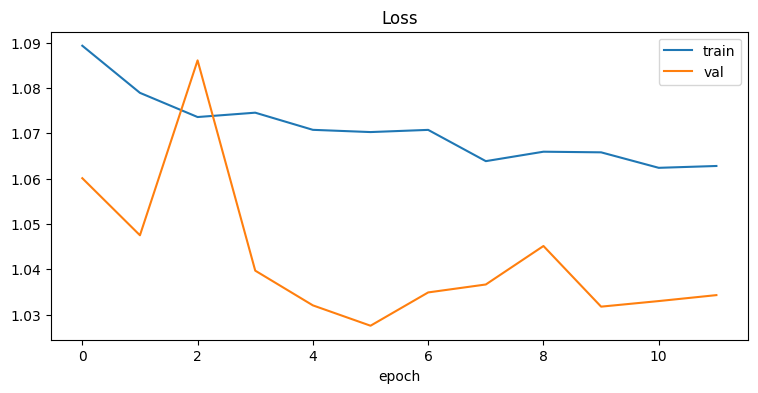

ValueError: Demasiado pocos trades OOS ejecutados: 0

In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) Gráfica simple de loss
# =========================
if "history" in globals() and isinstance(history, dict) and "train_loss" in history and "val_loss" in history:
    plt.figure(figsize=(9, 4))
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.title("Loss")
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

# =========================
# 1) Construir trades OOS ejecutados (ex) en rango df_test
# =========================
if "trades" not in globals():
    raise ValueError("No existe `trades` en memoria. Ejecuta antes el backtest que lo crea.")
if "df_test" not in globals():
    raise ValueError("No existe `df_test` en memoria.")

test_start = pd.to_datetime(df_test["datetime"], utc=True).min()
test_end   = pd.to_datetime(df_test["datetime"], utc=True).max()

ex = trades[
    (trades["datetime"] >= test_start) &
    (trades["datetime"] <= test_end) &
    (trades["signal"] != 0)
].copy().sort_values("datetime").reset_index(drop=True)

if len(ex) < 20:
    raise ValueError(f"Demasiado pocos trades OOS ejecutados: {len(ex)}")

# =========================
# 2) Métrica observada
# =========================
obs = ex["strat_logret"].astype(float).values
days = ex["datetime"].dt.floor("D").nunique()
tpd = len(ex) / max(days, 1)

obs_avg, obs_std = obs.mean(), obs.std(ddof=0)
obs_sharpe = (obs_avg / obs_std) * np.sqrt(252 * tpd) if obs_std > 0 else np.nan
obs_ret = np.exp(obs.sum()) - 1.0

print("OBS OOS (df_test)")
print(f"Executed trades: {len(ex)} | Days: {days} | Trades/day: {tpd:.2f}")
print(f"Total return: {obs_ret:.2%} | Sharpe(ann): {obs_sharpe:.2f}")

# columnas necesarias para los null tests
for c in ["fwd_logret_2h", "cost", "signal"]:
    if c not in ex.columns:
        raise ValueError(f"Falta la columna `{c}` en `ex`.")

fwd  = ex["fwd_logret_2h"].astype(float).values
cost = ex["cost"].astype(float).values
sig  = ex["signal"].astype(float).values

# =========================
# 3) PERM TEST (señal aleatoria)
# =========================
N = 5000
rng = np.random.default_rng(42)

sharpes_perm = np.empty(N, dtype=float)
rets_perm    = np.empty(N, dtype=float)

for i in range(N):
    sig_perm = rng.permutation(sig)  # rompe alineación señal-return
    strat = sig_perm * fwd - cost
    avg, std = strat.mean(), strat.std(ddof=0)
    sharpes_perm[i] = (avg / std) * np.sqrt(252 * tpd) if std > 0 else -np.inf
    rets_perm[i]    = np.exp(strat.sum()) - 1.0

p_sh_perm = (np.sum(sharpes_perm >= obs_sharpe) + 1) / (N + 1)
p_rt_perm = (np.sum(rets_perm    >= obs_ret)    + 1) / (N + 1)

print("\nPERM TEST (null = señal aleatoria)")
print(f"p-value Sharpe: {p_sh_perm:.4f} | null 95%: {np.quantile(sharpes_perm, 0.95):.2f}")
print(f"p-value Return: {p_rt_perm:.4f} | null 95%: {np.quantile(rets_perm, 0.95):.2%}")

plt.figure(figsize=(9, 4))
plt.hist(sharpes_perm[np.isfinite(sharpes_perm)], bins=60)
plt.axvline(obs_sharpe)
plt.title("PERM null: Sharpe")
plt.xlabel("Sharpe(ann)")
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(rets_perm[np.isfinite(rets_perm)], bins=60)
plt.axvline(obs_ret)
plt.title("PERM null: Total return")
plt.xlabel("Total return")
plt.show()

# =========================
# 4) SHIFT TEST (circular shift: preserva estructura temporal de la señal)
# =========================
sharpes_shift = np.empty(N, dtype=float)
rets_shift    = np.empty(N, dtype=float)

for i in range(N):
    k = rng.integers(1, len(sig))  # shift no-cero
    sig_shift = np.roll(sig, k)
    strat = sig_shift * fwd - cost
    avg, std = strat.mean(), strat.std(ddof=0)
    sharpes_shift[i] = (avg / std) * np.sqrt(252 * tpd) if std > 0 else -np.inf
    rets_shift[i]    = np.exp(strat.sum()) - 1.0

p_sh_shift = (np.sum(sharpes_shift >= obs_sharpe) + 1) / (N + 1)
p_rt_shift = (np.sum(rets_shift    >= obs_ret)    + 1) / (N + 1)

print("\nSHIFT TEST (null = misma señal pero desalineada)")
print(f"p-value Sharpe: {p_sh_shift:.4f} | null 95%: {np.quantile(sharpes_shift, 0.95):.2f}")
print(f"p-value Return: {p_rt_shift:.4f} | null 95%: {np.quantile(rets_shift, 0.95):.2%}")

plt.figure(figsize=(9, 4))
plt.hist(sharpes_shift[np.isfinite(sharpes_shift)], bins=60)
plt.axvline(obs_sharpe)
plt.title("SHIFT null: Sharpe")
plt.xlabel("Sharpe(ann)")
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(rets_shift[np.isfinite(rets_shift)], bins=60)
plt.axvline(obs_ret)
plt.title("SHIFT null: Total return")
plt.xlabel("Total return")
plt.show()
